In [14]:
import pandas as pd
import numpy as np

df = pd.read_excel("Filtered Data with Subtypes Again.xlsx")

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()

# Loop through each metric to calculate percent change
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    df[pct_col] = df.groupby("ein")[m].pct_change()
    df.loc[df["year_diff"] != 1, pct_col] = None

# Assign each org to a growth quartile bracket per metric, Year, Type, subtype
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    bracket_col = f"{m.lower()}_growth_bracket"

    def assign_quartile(group):
        # Only use rows with valid pct_change to compute quartile boundaries
        valid = group[pct_col].dropna()
        if len(valid) < 4:
            # Not enough data — put everyone in bracket 2 (middle) as fallback
            group[bracket_col] = 2
            return group
        q25 = valid.quantile(0.25)
        q50 = valid.quantile(0.50)
        q75 = valid.quantile(0.75)

        def label(val):
            if pd.isna(val):
                return np.nan
            elif val <= q25:
                return 1   # Bottom 25%
            elif val <= q50:
                return 2   # 26–50%
            elif val <= q75:
                return 3   # 51–75%
            else:
                return 4   # Top 25%

        group[bracket_col] = group[pct_col].apply(label)
        return group

    df = df.groupby(["Year", "Type", "subtype"], group_keys=False).apply(assign_quartile)

C:\Users\marsh\AppData\Local\Temp\ipykernel_6076\2400976227.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Year", "Type", "subtype"], group_keys=False).apply(assign_quartile)
C:\Users\marsh\AppData\Local\Temp\ipykernel_6076\2400976227.py:52: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["Year", "Type", "subtype"], group_keys=False).apply(assign_quartile)
c:\Users\mar

In [15]:
# Compute median growth per bracket, Year, Type, subtype for each metric
bracket_cols = [f"{m.lower()}_growth_bracket" for m in metrics]
pct_cols = [f"{m.lower()}_pct_change" for m in metrics]

# Build median growth per (Year, Type, subtype, bracket) for each metric separately
# then merge back

for m in metrics:
    pct_col = f"{m.lower()}_pct_change"
    bracket_col = f"{m.lower()}_growth_bracket"
    median_col = f"median_{m.lower()}_growth"

    bracket_medians = (
        df[df[pct_col].notna()]
        .groupby(["Year", "Type", "subtype", bracket_col])[pct_col]
        .median()
        .reset_index()
        .rename(columns={pct_col: median_col})
    )

    df = df.merge(bracket_medians, on=["Year", "Type", "subtype", bracket_col], how="left")

# Predict next year's value using each org's bracket-specific median growth
for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)
    df[f"predicted_{m.lower()}"] = prev_actual * (1 + df[f"median_{m.lower()}_growth"])

In [16]:
# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions", "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate Median Relative Deviation
def MRD(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() &
                    df[actual_col].notna() &
                    (df[actual_col] != 0) &
                    (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted)) / total_actual).median()
    return RE

def mean_relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna() & df[actual_col].notna() & (df[actual_col] != 0) & (df["year_diff"] == 1)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = (abs((total_actual - total_predicted))/total_actual).mean()
    return RE

def smape(actual_col, predicted_col):
    valid_rows = df[
        df[predicted_col].notna() &
        df[actual_col].notna() &
        (df["year_diff"] == 1)
    ]

    A = valid_rows[actual_col]
    P = valid_rows[predicted_col]

    return np.mean(np.abs(A - P) / ((np.abs(A) + np.abs(P)) / 2))

# Compute relative errors
RE_account = MRD("Accounts", "predicted_accounts")
RE_contributions = MRD("Contributions", "predicted_contributions")
RE_grants = MRD("Grants", "predicted_grants")
RE_assets = MRD("Assets", "predicted_assets")

Mean_account = mean_relative_error("Accounts", "predicted_accounts")
Mean_contributions = mean_relative_error("Contributions", "predicted_contributions")
Mean_grants = mean_relative_error("Grants", "predicted_grants")
Mean_assets = mean_relative_error("Assets", "predicted_assets")

smape_account = smape("Accounts", "predicted_accounts")
smape_contributions = smape("Contributions", "predicted_contributions")
smape_grants = smape("Grants", "predicted_grants")
smape_assets = smape("Assets", "predicted_assets")

print("Median Relative Deviation - Account:", abs(RE_account))
print("Median Relative Deviation - Contributions:", abs(RE_contributions))
print("Median Relative Deviation - Grants:", abs(RE_grants))
print("Median Relative Deviation - Assets:", abs(RE_assets))

print("")
print("Mean Relative Deviation - Account:", abs(Mean_account))
print("Mean Relative Deviation - Contributions:", abs(Mean_contributions))
print("Mean Relative Deviation - Grants:", abs(Mean_grants))
print("Mean Relative Deviation - Assets:", abs(Mean_assets))

print("")
print("SMAPE - Account:", abs(smape_account))
print("SMAPE - Contributions:", abs(smape_contributions))
print("SMAPE - Grants:", abs(smape_grants))
print("SMAPE - Assets:", abs(smape_assets))

Median Relative Deviation - Account: 0.016
Median Relative Deviation - Contributions: 0.19590530717691745
Median Relative Deviation - Grants: 0.10902664887237457
Median Relative Deviation - Assets: 0.03173827203202097

Mean Relative Deviation - Account: 0.09150282733659514
Mean Relative Deviation - Contributions: 0.920955798197074
Mean Relative Deviation - Grants: 1.0068654254506728
Mean Relative Deviation - Assets: 0.4479913973662865

SMAPE - Account: 0.0761398912263743
SMAPE - Contributions: 0.3831270538547532
SMAPE - Grants: 0.25813826470516077
SMAPE - Assets: 0.11781132026305997


In [18]:
df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]

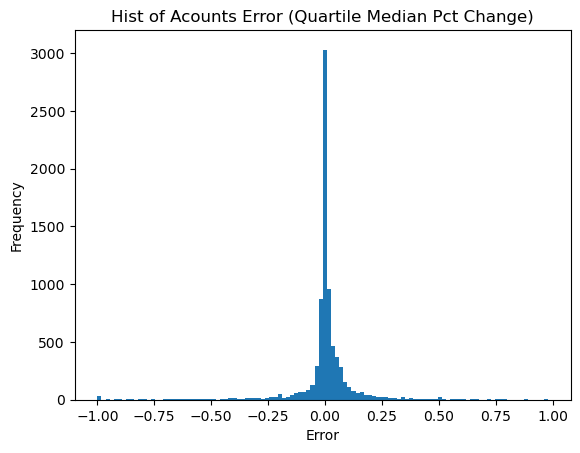

In [19]:
import matplotlib.pyplot as plt

df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error (Quartile Median Pct Change)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 3200) #
plt.show()

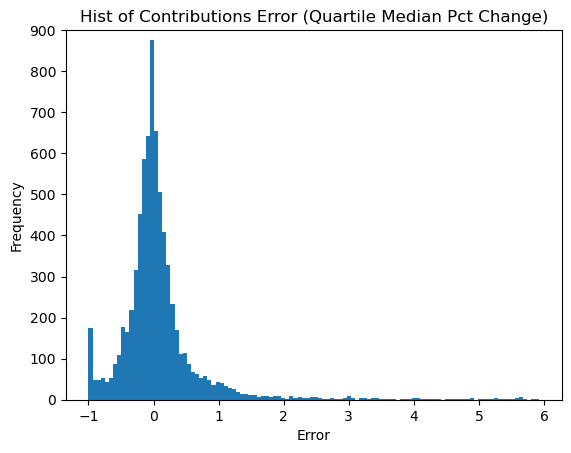

In [20]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error (Quartile Median Pct Change)")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.ylim(0, 900) #
plt.show()

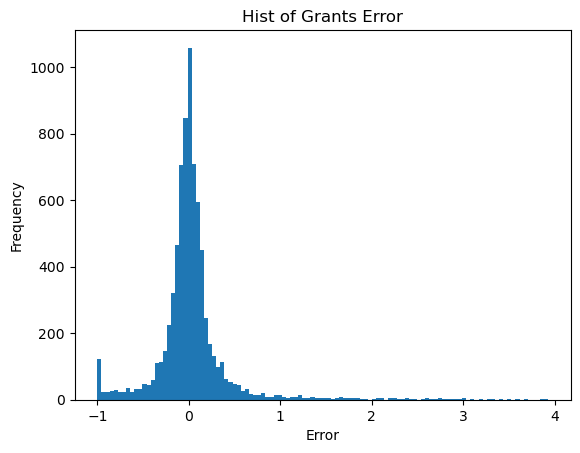

In [21]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

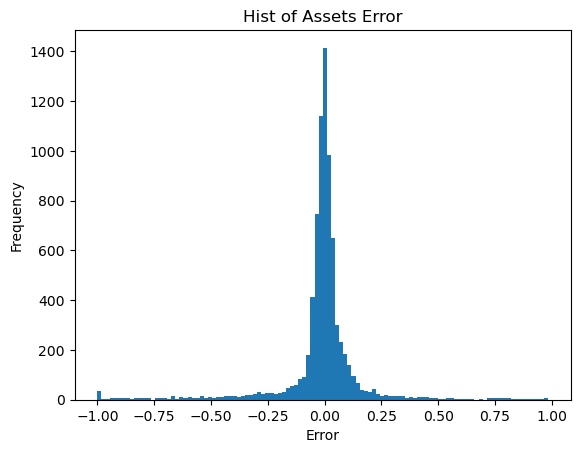

In [22]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

C:\Users\marsh\AppData\Local\Temp\ipykernel_6076\4129015181.py:5: RuntimeWarning: invalid value encountered in scalar divide
  RE = abs((total_actual - total_predicted)).sum() / len(total_actual)


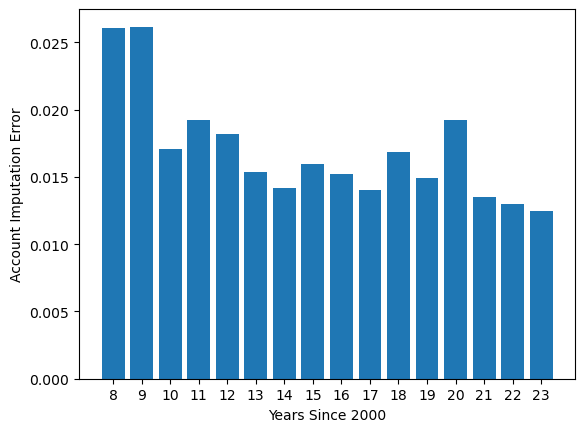

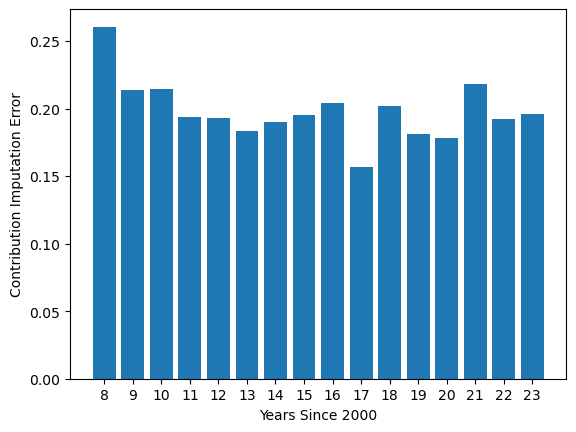

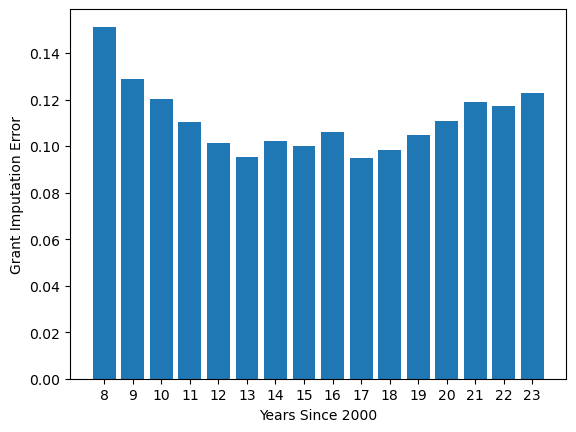

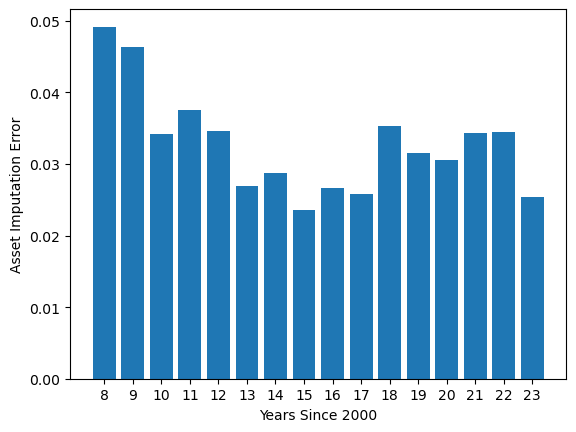

In [23]:
def relative_grouped_error(actual_col, predicted_col):
    valid_rows = group[group[predicted_col].notna()&group[actual_col].notna()&(group[actual_col] !=0)]
    total_actual = valid_rows[actual_col]
    total_predicted = valid_rows[predicted_col]
    RE = abs((total_actual - total_predicted)).sum() / len(total_actual)
    ME =(abs((total_actual - total_predicted)/total_actual)).median()
    return ME

RE_account_by_year = []
RE_contributions_by_year = []
RE_grants_by_year = []
RE_assets_by_year = []

grouped = df.groupby("Year")
for year, group in grouped:
    RE_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    RE_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    RE_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    RE_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

# def relative_grouped_error(actual_col, predicted_col):
#     valid_rows = group[group[predicted_col].notna()]
#     total_actual = valid_rows[actual_col].sum()
#     total_predicted = valid_rows[predicted_col].sum()
#     RE = abs((total_actual - total_predicted) / total_actual)
#     return RE

community_account_by_year = []
community_contributions_by_year = []
community_grants_by_year = []
community_assets_by_year = []

national_account_by_year = []
national_contributions_by_year = []
national_grants_by_year = []
national_assets_by_year = []

single_account_by_year = []
single_contributions_by_year = []
single_grants_by_year = []
single_assets_by_year = []

community_df = df[df["Type"] == "Community Foundation"]
cgroups = community_df.groupby("subtype")
for subtype, group in cgroups:
    community_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    community_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    community_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    community_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

national_df = df[df["Type"] == "National"]
ngroups = national_df.groupby("subtype")
for subtype, group in ngroups:
    national_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    national_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    national_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    national_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))

single_df = df[df["Type"] == "Single Issue Charity"]
sgroups = single_df.groupby("subtype")
for subtype, group in sgroups:
    single_account_by_year.append(relative_grouped_error("Accounts", "predicted_accounts"))
    single_contributions_by_year.append(relative_grouped_error("Contributions", "predicted_contributions"))
    single_grants_by_year.append(relative_grouped_error("Grants", "predicted_grants"))
    single_assets_by_year.append(relative_grouped_error("Assets", "predicted_assets"))
#2024 is discounted from these graphs because the error is exponentially greater than the rest
#2020/2021 was Covid, 2014 was when the stock market rebounded, and 2008/2009 was an economic recession
account_error_by_year = RE_account_by_year[1:-1]
contribution_error_by_year = RE_contributions_by_year[1:-1]
grant_error_by_year = RE_grants_by_year[1:-1]
asset_error_by_year = RE_assets_by_year[1:-1]

Year = range(7, 23)

plt.bar(Year, account_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Account Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, contribution_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Contribution Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, grant_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Grant Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()

plt.bar(Year, asset_error_by_year)
plt.xlabel("Years Since 2000")
plt.ylabel("Asset Imputation Error")
plt.xticks(Year, [str(i+1) for i in Year])
plt.show()